In [2]:
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import time
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score, plot_confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')



In [3]:
data = pd.read_csv('cleaned_data.csv', index_col=0)
x = data.iloc[:, 1:-1]
y = data.iloc[:,-1]
y,x
x_train_and_val, x_test, y_train_and_val, y_test = train_test_split(x, y, test_size = 0.15, random_state = 1)
x_train, x_val, y_train, y_val = train_test_split(x_train_and_val, y_train_and_val, test_size = 0.15 / .85, random_state = 1)

In [5]:
#m = [[1,2],[3,4]]

def FPR(arr):
    # false positive / false positive + true negative
    return arr[0][1] / (arr[0][1] + arr[0][0])
    

In [10]:

train_size = x_train.shape[0]

c =  1 :  13.174803256988525
c =  2 :  25.31286597251892
c =  3 :  2.08479905128479
c =  4 :  18.178083181381226
c =  5 :  22.863192081451416
c =  6 :  13.104840755462646
c =  7 :  6.896410703659058
c =  8 :  15.369426965713501


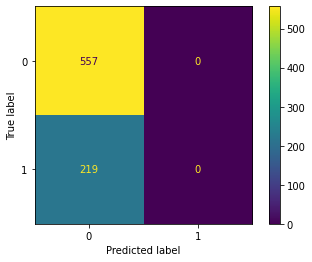

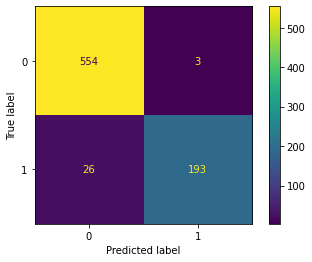

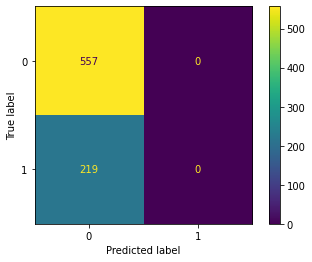

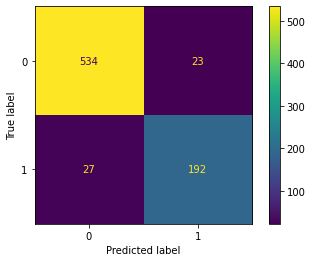

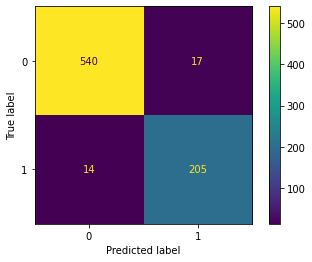

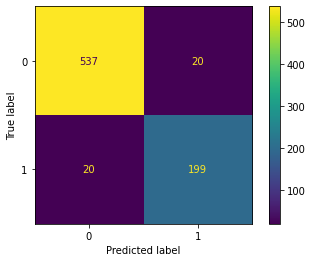

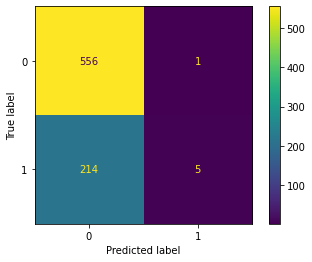

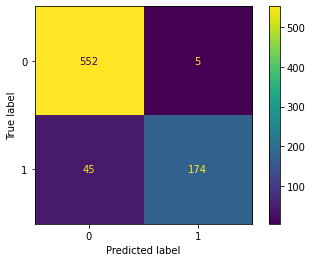

In [11]:
# layers
results_sgd = {}
accuracy = {}
for c in range(1,9):
    mlp = MLPClassifier(hidden_layer_sizes=(8,c), activation='relu', solver='sgd', max_iter=500, learning_rate_init = 0.001)
    start = time.time()
    mlp.fit(x_train,y_train)
    end = time.time()
    print("c = ", c, ": ", end - start)
    result = mlp.predict(x_val)
    #results_sgd[c] = accuracy_score(y_val, result)
    m = confusion_matrix(y_val, result)
    results_sgd[c] = roc_auc_score(y_val, result)
    accuracy[c] = accuracy_score(y_val, result)
    

In [12]:
results_sgd

{1: 0.5,
 2: 0.9379462712017249,
 3: 0.5,
 4: 0.9177098448144413,
 5: 0.9527762065205807,
 6: 0.9363845781789266,
 7: 0.5105178590459326,
 8: 0.8927719436314896}

In [12]:
# neurons 
results_sgd_neurons = {}
acc_score = {}
maxAUC = 0
for n in range(4,33, 4):
    mlp = MLPClassifier(hidden_layer_sizes=(n, 5), activation='relu', solver='sgd', max_iter=500)
    start = time.time()
    mlp.fit(x_train,y_train)
    end = time.time()
    print("# of neurons = ", n, ": ", end - start)
    result = mlp.predict(x_val)
    results_sgd_neurons[n] = roc_auc_score(y_val, result)
    acc_score[n] = accuracy_score(y_val, result)
    

  

# of neurons =  4 :  13.778613805770874
# of neurons =  8 :  26.31537890434265
# of neurons =  12 :  10.052265882492065
# of neurons =  16 :  12.600284099578857
# of neurons =  20 :  13.116940021514893
# of neurons =  24 :  6.16885781288147
# of neurons =  28 :  10.249220132827759
# of neurons =  32 :  16.602545976638794


In [33]:
# batch gradient descent
baseline_model = MLPClassifier(hidden_layer_sizes=(16, 5), activation='relu', solver='sgd', max_iter=1000, batch_size = train_size, learning_rate_init = 0.0001)
start = time.time()
baseline_model.fit(x_train, y_train)
end = time.time()
print(end - start)
result = baseline_model.predict(x_val)
print(accuracy_score(y_val, result))
print(roc_auc_score(y_val, result))
print(FPR(confusion_matrix(y_val, result)))

141.15824031829834
0.875
0.8034767139683399
0.03231597845601436


In [29]:
#stochastic
model = MLPClassifier(hidden_layer_sizes=(16, 5), activation='relu', solver='sgd', max_iter=1000, learning_rate_init = 0.0001)
start = time.time()
model.fit(x_train, y_train)
end = time.time()
print(end - start)
result = model.predict(x_val)
print(accuracy_score(y_val, result))
print(roc_auc_score(y_val, result))
print(FPR(confusion_matrix(y_val, result)))

176.65961909294128
0.9768041237113402
0.9699876212259085
0.01436265709156194


In [19]:
# try sgd (no momentum) versus adam

result = best_model.predict(x_val)
print(accuracy_score(y_val, result))
print(roc_auc_score(y_val, result))

0.961340206185567
0.9425903609519359


In [35]:
# try adam 
mlp_adam = MLPClassifier(hidden_layer_sizes=(16, 5), activation='relu', solver='adam', max_iter=500, learning_rate_init = 0.0001)
start = time.time()
mlp_adam.fit(x_train,y_train)
end = time.time()
print(end - start)
result = mlp_adam.predict(x_val)
print(accuracy_score(y_val, result))
print(roc_auc_score(y_val, result))
print(FPR(confusion_matrix(y_val, result)))

42.44882273674011
0.9845360824742269
0.9823008124082864
0.012567324955116697


In [6]:
# try adam 
mlp_adam = MLPClassifier(hidden_layer_sizes=(16, 5), activation='relu', solver='adam', max_iter=500, learning_rate_init = 0.0001)
start = time.time()
mlp_adam.fit(x_train_and_val,y_train_and_val)
end = time.time()
print(end - start)
result = mlp_adam.predict(x_test)
print(accuracy_score(y_test, result))
print(roc_auc_score(y_test, result))
print(FPR(confusion_matrix(y_test, result)))

33.859867811203
0.9858247422680413
0.9812952995202302
0.007366482504604052
